In [1]:
#importing required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans 
# importing the StandardScaler Module
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.ticker as mtick # For specifying the axes tick format 
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.decomposition import PCA

In [2]:
#Read ‘vehicle.csv’ and save as DataFrame
dataset=pd.read_csv("vehicle.csv")
dataset.head(5)

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [3]:
#5 point summary
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
compactness,846.0,93.678487,8.234474,73.0,87.00,93.0,100.0,119.0
circularity,841.0,44.828775,6.152172,33.0,40.00,44.0,49.0,59.0
distance_circularity,842.0,82.110451,15.778292,40.0,70.00,80.0,98.0,112.0
radius_ratio,840.0,168.888095,33.520198,104.0,141.00,167.0,195.0,333.0
pr.axis_aspect_ratio,844.0,61.678910,7.891463,47.0,57.00,61.0,65.0,138.0
max.length_aspect_ratio,846.0,8.567376,4.601217,2.0,7.00,8.0,10.0,55.0
scatter_ratio,845.0,168.901775,33.214848,112.0,147.00,157.0,198.0,265.0
elongatedness,845.0,40.933728,7.816186,26.0,33.00,43.0,46.0,61.0
pr.axis_rectangularity,843.0,20.582444,2.592933,17.0,19.00,20.0,23.0,29.0
max.length_rectangularity,846.0,147.998818,14.515652,118.0,137.00,146.0,159.0,188.0


In [4]:
#display dataset
dataset.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [5]:
dataset.isna().sum()

compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64

In [6]:
#Check percentage of missing values and impute with correct approach
(((dataset.isna().sum())/846)*100)

compactness                    0.000000
circularity                    0.591017
distance_circularity           0.472813
radius_ratio                   0.709220
pr.axis_aspect_ratio           0.236407
max.length_aspect_ratio        0.000000
scatter_ratio                  0.118203
elongatedness                  0.118203
pr.axis_rectangularity         0.354610
max.length_rectangularity      0.000000
scaled_variance                0.354610
scaled_variance.1              0.236407
scaled_radius_of_gyration      0.236407
scaled_radius_of_gyration.1    0.472813
skewness_about                 0.709220
skewness_about.1               0.118203
skewness_about.2               0.118203
hollows_ratio                  0.000000
class                          0.000000
dtype: float64

In [7]:
dataset=dataset.dropna()

In [8]:
#5 point summary
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
compactness,813.0,93.656827,8.233751,73.0,87.0,93.0,100.0,119.0
circularity,813.0,44.803198,6.146659,33.0,40.0,44.0,49.0,59.0
distance_circularity,813.0,82.043050,15.783070,40.0,70.0,79.0,98.0,112.0
radius_ratio,813.0,169.098401,33.615402,104.0,141.0,167.0,195.0,333.0
pr.axis_aspect_ratio,813.0,61.774908,7.973000,47.0,57.0,61.0,65.0,138.0
max.length_aspect_ratio,813.0,8.599016,4.677174,2.0,7.0,8.0,10.0,55.0
scatter_ratio,813.0,168.563346,33.082186,112.0,146.0,157.0,198.0,265.0
elongatedness,813.0,40.988930,7.803380,26.0,33.0,43.0,46.0,61.0
pr.axis_rectangularity,813.0,20.558426,2.573184,17.0,19.0,20.0,23.0,29.0
max.length_rectangularity,813.0,147.891759,14.504648,118.0,137.0,146.0,159.0,188.0


In [9]:
dataset.isna().sum()

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

In [10]:
(((dataset.isna().sum())/813)*100)

compactness                    0.0
circularity                    0.0
distance_circularity           0.0
radius_ratio                   0.0
pr.axis_aspect_ratio           0.0
max.length_aspect_ratio        0.0
scatter_ratio                  0.0
elongatedness                  0.0
pr.axis_rectangularity         0.0
max.length_rectangularity      0.0
scaled_variance                0.0
scaled_variance.1              0.0
scaled_radius_of_gyration      0.0
scaled_radius_of_gyration.1    0.0
skewness_about                 0.0
skewness_about.1               0.0
skewness_about.2               0.0
hollows_ratio                  0.0
class                          0.0
dtype: float64

Text(0.5, 1.0, '% of class')

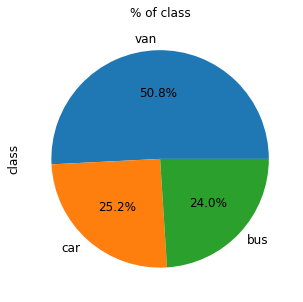

In [11]:
#Visualize a Pie-chart and print percentage of values for variable ‘class
lab=dataset['class'].unique()
ax = (dataset['class'].value_counts()*100.0 /len(dataset))\
.plot.pie(autopct='%.1f%%', labels = lab,figsize =(5,5), fontsize = 12 )                                                                           
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('class',fontsize = 12)
ax.set_title('% of class', fontsize = 12)

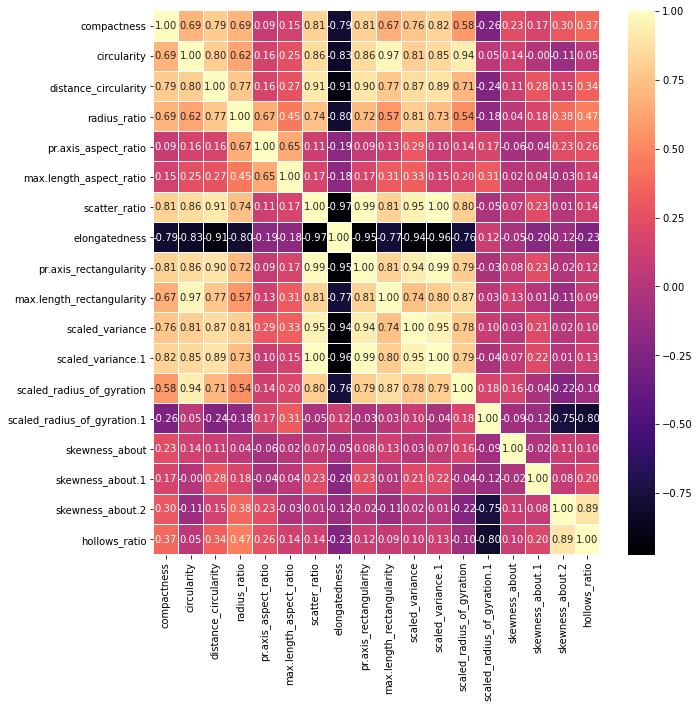

In [12]:
# the color intensity 
fig,ax = plt.subplots(figsize=(10, 10))
sns.heatmap(dataset.corr(), ax=ax, annot=True, linewidths=0.05, fmt= '.2f',cmap="magma") 
plt.show()

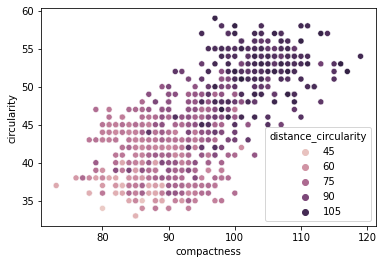

In [13]:
#Visualize a scatterplot for ‘wt’ and ‘disp’. Datapoints are distinguishable by ‘cyl’
sns.scatterplot(x="compactness",y="circularity",hue="distance_circularity",data=dataset)
plt.show()

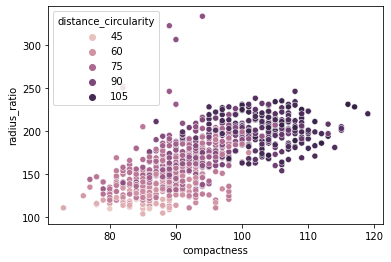

In [14]:
#Visualize a scatterplot for ‘wt’ and ‘mpg’. Datapoints are distinguishable by ‘cyl’
sns.scatterplot(x="compactness",y="radius_ratio",hue="distance_circularity",data=dataset)
plt.show()

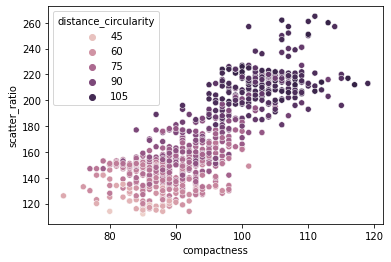

In [15]:
#Visualize a scatterplot for ‘wt’ and ‘mpg’. Datapoints are distinguishable by ‘cyl’
sns.scatterplot(x="compactness",y="scatter_ratio",hue="distance_circularity",data=dataset)
plt.show()

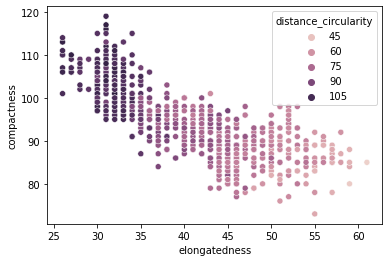

In [16]:
#Visualize a scatterplot for ‘wt’ and ‘mpg’. Datapoints are distinguishable by ‘cyl’
sns.scatterplot(x="elongatedness",y="compactness",hue="distance_circularity",data=dataset)
plt.show()

In [17]:
#Check for duplicate rows in the data and impute with correct approach
dataset.duplicated().sum()

0

In [18]:
correlation = dataset.corr()
correlation


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
compactness,1.000000,0.689885,0.789955,0.688130,0.090557,0.150369,0.814026,-0.788051,0.814227,0.674902,0.764386,0.820240,0.581405,-0.258437,0.231648,0.168384,0.296195,0.372806
circularity,0.689885,1.000000,0.797704,0.623950,0.155023,0.251619,0.858149,-0.825108,0.856137,0.965366,0.806108,0.850932,0.935594,0.049070,0.141726,-0.001975,-0.113902,0.049331
distance_circularity,0.789955,0.797704,1.000000,0.771404,0.163386,0.265591,0.909023,-0.912713,0.897261,0.773459,0.865683,0.891789,0.705689,-0.238145,0.110280,0.277851,0.145258,0.343228
radius_ratio,0.688130,0.623950,0.771404,1.000000,0.667375,0.452460,0.743470,-0.795761,0.716210,0.570478,0.806788,0.731773,0.544636,-0.175348,0.044693,0.178079,0.375591,0.470895
pr.axis_aspect_ratio,0.090557,0.155023,0.163386,0.667375,1.000000,0.652093,0.113696,-0.191193,0.086992,0.133553,0.290375,0.100668,0.135663,0.173060,-0.059244,-0.040769,0.229702,0.257566
max.length_aspect_ratio,0.150369,0.251619,0.265591,0.452460,0.652093,1.000000,0.171445,-0.183242,0.167514,0.309180,0.331124,0.150069,0.197179,0.308329,0.016461,0.041210,-0.030543,0.139283
scatter_ratio,0.814026,0.858149,0.909023,0.743470,0.113696,0.171445,1.000000,-0.973413,0.991992,0.808154,0.950067,0.996396,0.795748,-0.045632,0.070118,0.227375,0.009967,0.138424
elongatedness,-0.788051,-0.825108,-0.912713,-0.795761,-0.191193,-0.183242,-0.973413,1.000000,-0.950345,-0.771099,-0.937846,-0.956858,-0.761563,0.119750,-0.046621,-0.201325,-0.117568,-0.233408
pr.axis_rectangularity,0.814227,0.856137,0.897261,0.716210,0.086992,0.167514,0.991992,-0.950345,1.000000,0.811979,0.935653,0.992119,0.792895,-0.033769,0.078701,0.231171,-0.017383,0.117202
max.length_rectangularity,0.674902,0.965366,0.773459,0.570478,0.133553,0.309180,0.808154,-0.771099,0.811979,1.000000,0.744760,0.796230,0.865240,0.031098,0.130356,0.013045,-0.108019,0.086792


In [19]:
#encoding the catagorical values (target variable 0 is bus,1 is car and 2 is van  )
dataset['class']=dataset['class'].astype('category')
dataset['class']=dataset['class'].cat.codes
dataset.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,2
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,2
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,1
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,2
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,0


In [20]:
#Split data into X and Y. [Train and Test optional] 
#Standardize the Data
X=dataset.drop('class', axis=1)
y=dataset['class']
X_Scaler = StandardScaler()
X_scaled = X_Scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=1)

In [21]:
#Train a base Classification model using SVM
clf = svm.SVC(gamma=0.010, C=95) 
clf.fit(X_train , y_train)
y_predict = clf.predict(X_test)
print("Accuracy : %1.4f " %(accuracy_score(y_test, y_predict)*100))

Accuracy : 98.5294 


In [22]:
from sklearn.metrics import precision_recall_fscore_support, mean_absolute_error
print('\nMean Absolute Error of SVM:\n', mean_absolute_error(y_test, y_predict))


Mean Absolute Error of SVM:
 0.0196078431372549


<AxesSubplot:>

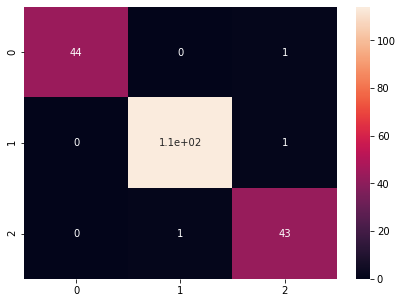

In [23]:
#Print Classification metrics for train data
df_cm= confusion_matrix(y_test, y_predict)
plt.figure(figsize = (7,5))
sns.heatmap(df_cm, annot=True)

In [24]:
# Creating an object for the StandardScaler function to normailze the values
XScaler = StandardScaler()
scaled_df = XScaler.fit_transform(dataset.iloc[:,1:9])
scaled_df

array([[ 0.52040788,  0.06066872,  0.26497017, ..., -0.19851729,
         0.12964799, -0.21715097],
       [-0.61912319,  0.12406675, -0.83639333, ..., -0.59171992,
         0.51433345, -0.60601383],
       [ 0.84598818,  1.51882349,  1.18773418, ...,  1.16256874,
        -1.15263688,  0.94943761],
       ...,
       [ 1.49714879,  1.20183332,  1.57469973, ...,  1.61626408,
        -1.40909386,  1.72716333],
       [-1.43307395, -0.25632145, -0.68756042, ..., -1.0151689 ,
         1.15547589, -0.99487669],
       [-1.43307395, -1.01709784, -1.37219178, ..., -1.46886425,
         1.92484682, -1.38373955]])

Text(0.5, 1.0, 'Selecting k with the Elbow Method')

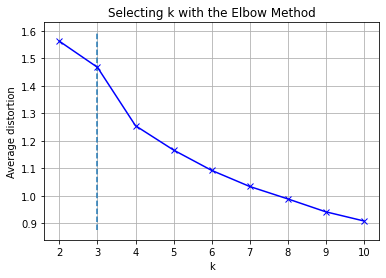

In [25]:
#Apply K-Means clustering for 2 to 10 clusters.
#Plot a visual and find elbow point. 
#On the above visual, highlight which are the possible Elbow points. 
#Finding optimal no. of clusters
clusters=range(2,11)
meanDistortions=[]

#forming models for 2 to 10
for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(scaled_df)
    prediction=model.predict(scaled_df)
    meanDistortions.append(sum(np.min(cdist(scaled_df, model.cluster_centers_, 'euclidean'), axis=1)) / scaled_df.shape[0])

# ploting visual and find elbow point
plt.plot(clusters, meanDistortions, 'bx-')
plt.xlabel('k')
plt.grid()
plt.vlines(3, plt.ylim()[0], plt.ylim()[1], linestyles='dashed')
plt.ylabel('Average distortion')
plt.title('Selecting k with the Elbow Method')

In [26]:
#Train a K-means clustering model once again on the optimal number of clusters.
# Let us first start with K = 3
final_model=KMeans(3)
final_model.fit(scaled_df)
prediction=final_model.predict(scaled_df)
dataset['cluster'] = final_model.fit_predict(scaled_df)
labels=final_model.labels_
test=silhouette_score(scaled_df,labels)
print("silhouette_score: %1.4f" %test)
#Append the prediction 
dataset["GROUP"] = prediction
print("Groups Assigned : \n")
dataset.head(3)

silhouette_score: 0.5364
Groups Assigned : 



,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,...,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class,cluster,GROUP
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,...,379.0,184.0,70.0,6.0,16.0,187.0,197,2,1,1
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,...,330.0,158.0,72.0,9.0,14.0,189.0,199,2,1,1
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,...,635.0,220.0,73.0,14.0,9.0,188.0,196,1,0,0


In [30]:
print(f"For n_clusters = {clusters}, the average silhouette score is: {test:.3f}")

For n_clusters = range(2, 11), the average silhouette score is: 0.536
